<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_9_Sequential_cosine_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

# Part_1:Sequential Cosine Similarity in one sentence

## Task_1:
- Import the BERT tokenizer and model, and extract the embeddings
matrix.
Tokenize the sentence, calculate the cosine similarity between
each token and the previous using the cosine_similarity function,
and visualize the results in a bar plot as in Figure 3.12

In [2]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
embeddings = model.embeddings.word_embeddings.weight.detach()
print(f'Embedding matrix shape: {embeddings.shape}')

Embedding matrix shape: torch.Size([30522, 768])


In [4]:

sentence = "my phone is in the kitchen near the cold ice cream"

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

In [14]:
tokens=tokenizer.encode(sentence)[1:-1]

In [15]:
tokens

[2026, 3042, 2003, 1999, 1996, 3829, 2379, 1996, 3147, 3256, 6949]

### each word with the next word cosine similarity

In [16]:
for i in range(len(tokens)-1):
  x=tokens[i],tokens[i+1]
  print(x)

(2026, 3042)
(3042, 2003)
(2003, 1999)
(1999, 1996)
(1996, 3829)
(3829, 2379)
(2379, 1996)
(1996, 3147)
(3147, 3256)
(3256, 6949)


In [17]:
cosim=np.full(len(tokens),np.nan)

In [18]:
cosim

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [28]:
for i in range(len(tokens)-1):
  v1=embeddings[tokens[i]]
  v2=embeddings[tokens[i+1]]
  sim=cosine_similarity(v1.reshape(1,-1),v2.reshape(1,-1))
  cosim[i]=sim.item()

In [29]:
cosim

array([0.17132275, 0.09739193, 0.40583223, 0.50275862, 0.11723182,
       0.16011541, 0.17803752, 0.18088165, 0.37536353, 0.28223613,
              nan])

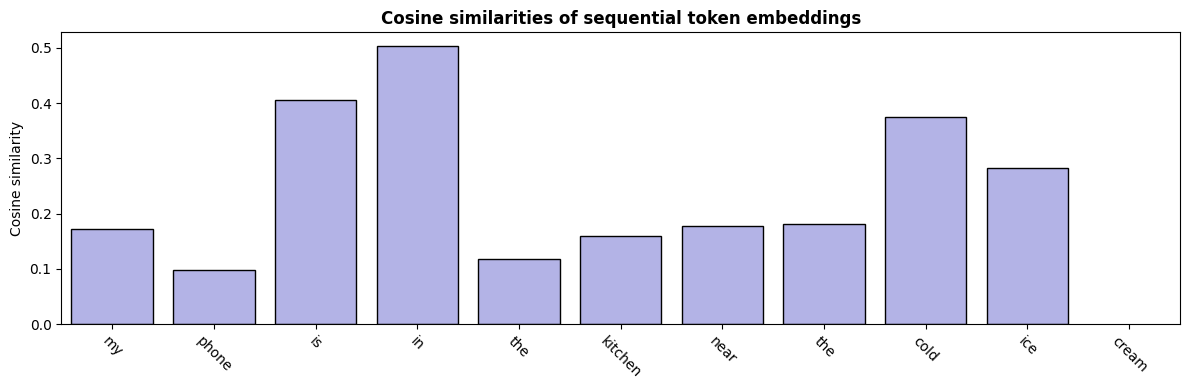

In [30]:
plt.figure(figsize=(12,4))
plt.bar(np.arange(len(cosim)),cosim,facecolor=[.7,.7,.9],edgecolor='k')
plt.gca().set(xticks=range(len(tokens)),xticklabels=[tokenizer.decode(t) for t in tokens],
              xlim=[-.5,len(tokens)-.5],ylabel='Cosine similarity')
plt.gca().tick_params(axis='x',rotation=-45)

plt.title('Cosine similarities of sequential token embeddings',fontweight='bold')

plt.tight_layout()
plt.show()

### each worrd with prev word similairty

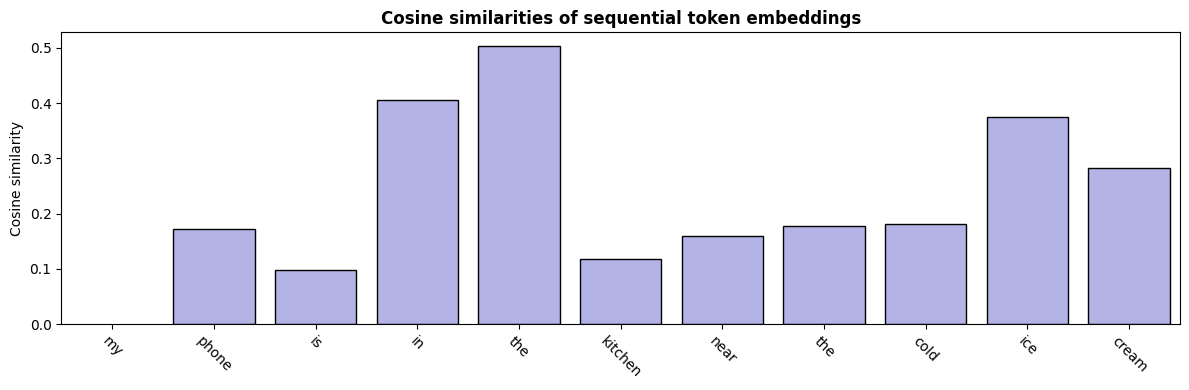

In [31]:
sentence = "my phone is in the kitchen near the cold ice cream"

# tokenize the sentence
tokens = tokenizer.encode(sentence)[1:-1] # ignore the cls/sep tokens

# initialize cosine similarity
cossim = np.full(len(tokens),np.nan)

# calculate cosine similarity for successive word pairs
for ti in range(1,len(tokens)):
  v1 = embeddings[tokens[ti],:]
  v2 = embeddings[tokens[ti-1],:]
  c = cosine_similarity(v1.reshape(1,-1),v2.reshape(1,-1))
  cossim[ti] = c.item()


# plot!
plt.figure(figsize=(12,4))
plt.bar(np.arange(len(cossim)),cossim,facecolor=[.7,.7,.9],edgecolor='k')
plt.gca().set(xticks=range(len(tokens)),xticklabels=[tokenizer.decode(t) for t in tokens],
              xlim=[-.5,len(tokens)-.5],ylabel='Cosine similarity')
plt.gca().tick_params(axis='x',rotation=-45)

plt.title('Cosine similarities of sequential token embeddings',fontweight='bold')

plt.tight_layout()
plt.show()

# Part_2:Are Embeddings vectors context dependent?

## Task_1:
- Write code to produce Figure 3.13, which shows sequential cosine
similarity for the two sentences.

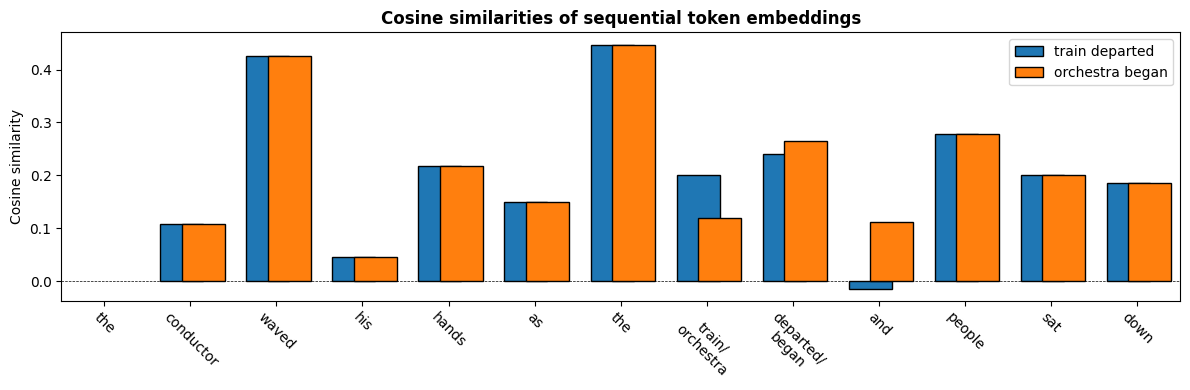

In [34]:

sentences = [
    'The conductor waved his hands as the train departed and people sat down',
    'The conductor waved his hands as the orchestra began and people sat down'
]


plt.figure(figsize=(12,4))

for i,sent in enumerate(sentences):

  # tokenize the sentence
  tokens = tokenizer.encode(sent)[1:-1]

  # initialize cosine similarity
  cossim = np.full(len(tokens),np.nan)

  # cosine similarity for successive word pairs
  for ti in range(1,len(tokens)):
    v1 = embeddings[tokens[ti],:]
    v2 = embeddings[tokens[ti-1],:]
    c = cosine_similarity(v1.reshape(1,-1),v2.reshape(1,-1))
    cossim[ti] = c.item()


  # plot!
  plt.bar(np.arange(0,len(cossim))+i/4-.1,cossim,width=.5,edgecolor='k',
          label=tokenizer.decode(tokens[7:9]))



# finish the plot
plt.axhline(0,linestyle='--',color='k',linewidth=.5,zorder=-3)
xticklabs = [tokenizer.decode(t) for t in tokens]
xticklabs[7] = f'train/\norchestra'
xticklabs[8] = 'departed/\nbegan'
plt.gca().set(xticks=range(len(tokens)),xticklabels=xticklabs,
              xlim=[-.5,len(tokens)-.5],ylabel='Cosine similarity')
plt.tick_params(axis='x',rotation=-45)
plt.legend()
plt.title('Cosine similarities of sequential token embeddings',fontweight='bold')

plt.tight_layout()
plt.show()

